# 📋 Hotel Booking Dataset - Feature Description

| Feature | Description |
|---------|-------------|
| **hotel** | Type of hotel (City Hotel or Resort Hotel). |
| **is_canceled** | Booking cancellation status (**0 = Not Canceled, 1 = Canceled**). |
| **lead_time** | Number of days between booking date and arrival date. |
| **arrival_date_year** | Year of arrival. |
| **arrival_date_month** | Month of arrival. |
| **arrival_date_week_number** | Week number of the arrival date. |
| **arrival_date_day_of_month** | Day of the month of arrival. |
| **stays_in_weekend_nights** | Number of weekend nights (Saturday/Sunday) booked. |
| **stays_in_week_nights** | Number of weekday nights booked. |
| **adults** | Number of adults included in the booking. |
| **children** | Number of children included in the booking. |
| **babies** | Number of babies included in the booking. |
| **meal** | Type of meal package booked (e.g., BB, HB, FB, SC). |
| **country** | Country of origin of the guest. |
| **market_segment** | Market segment through which the booking was made (e.g., Online TA, Corporate, Direct). |
| **distribution_channel** | Booking distribution channel (e.g., Travel Agent, Direct, Corporate). |
| **is_repeated_guest** | Indicates whether the customer is a returning guest (**0 = No, 1 = Yes**). |
| **previous_cancellations** | Number of previous bookings canceled by the customer. |
| **previous_bookings_not_canceled** | Number of previous bookings completed successfully. |
| **reserved_room_type** | Room type originally reserved by the customer. |
| **assigned_room_type** | Room type assigned by the hotel at check-in. |
| **booking_changes** | Number of modifications made to the booking before arrival. |
| **deposit_type** | Type of deposit associated with the booking. |
| **agent** | Unique identifier of the travel agent responsible for the booking. |
| **days_in_waiting_list** | Number of days the booking remained on the waiting list. |
| **customer_type** | Category of customer (e.g., Transient, Contract, Group). |
| **adr** | Average Daily Rate (average room price per night). |
| **required_car_parking_spaces** | Number of parking spaces requested by the customer. |
| **total_of_special_requests** | Total number of special requests made by the customer. |
| **reservation_status** | Final status of the reservation (e.g., Check-Out, Canceled, No-Show). |
| **reservation_status_date** | Date on which the reservation status was last updated. |

---
**Dataset Shape:** **31 Features**

## 1. Setup & Imports

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\youss\.cache\kagglehub\datasets\jessemostipak\hotel-booking-demand\versions\1


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,roc_curve,
    precision_recall_curve,average_precision_score
)
# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [3]:
%pip install catboost

In [4]:
import os

In [5]:
os.listdir(path)

['hotel_bookings.csv']

## 2. Load Data

In [6]:
df=pd.read_csv(path+'/hotel_bookings.csv')

In [7]:
df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## 3. Data Cleaning

In [9]:
df.isna().sum().sort_values(ascending=False).head(5)

company               112593
agent                  16340
country                  488
children                   4
arrival_date_month         0
dtype: int64

In [10]:
df.drop('company',axis=1,inplace=True)

In [11]:
df.duplicated().sum()

np.int64(32001)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.reset_index(drop=True,inplace=True)

In [14]:
df.isna().sum().sort_values(ascending=False).head(5)

agent                 12189
country                 452
children                  4
arrival_date_year         0
arrival_date_month        0
dtype: int64

In [15]:
df.dropna(subset=['country','children'],inplace=True)

In [16]:
df.reset_index(drop=True,inplace=True)

In [17]:
df.isna().sum().sort_values(ascending=False).head(5)

agent                 11862
is_canceled               0
hotel                     0
arrival_date_year         0
arrival_date_month        0
dtype: int64

In [18]:
df.describe().round(2)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,86933.00,86933.0,86933.00,86933.00,86933.00,86933.00,86933.00,86933.00,86933.00,86933.00,86933.00,86933.00,86933.00,86933.00,75071.00,86933.00,86933.00,86933.00,86933.00
mean,0.28,80.2,2016.21,26.84,15.82,1.01,2.63,1.88,0.14,0.01,0.04,0.03,0.18,0.27,93.93,0.75,106.58,0.08,0.70
std,0.45,86.1,0.69,13.65,8.83,1.03,2.04,0.63,0.46,0.11,0.19,0.37,1.72,0.73,113.11,10.04,54.96,0.28,0.83
min,0.00,0.0,2015.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,-6.38,0.00,0.00
25%,0.00,12.0,2016.00,16.00,8.00,0.00,1.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,9.00,0.00,72.25,0.00,0.00
50%,0.00,50.0,2016.00,27.00,16.00,1.00,2.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,14.00,0.00,98.40,0.00,0.00
75%,1.00,125.0,2017.00,37.00,23.00,2.00,4.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,240.00,0.00,134.10,0.00,1.00
max,1.00,737.0,2017.00,53.00,31.00,16.00,41.00,55.00,10.00,10.00,1.00,26.00,72.00,21.00,535.00,391.00,5400.00,8.00,5.00


## 4. Exploratory Data Analysis

<Axes: >

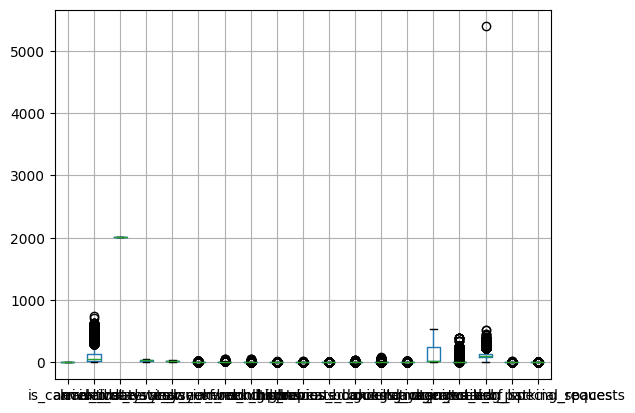

In [19]:
df.boxplot()

In [20]:
sns.boxplot(df.lead_time)

<Axes: ylabel='lead_time'>

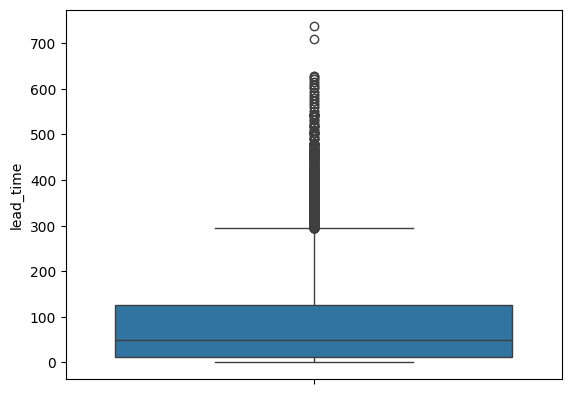

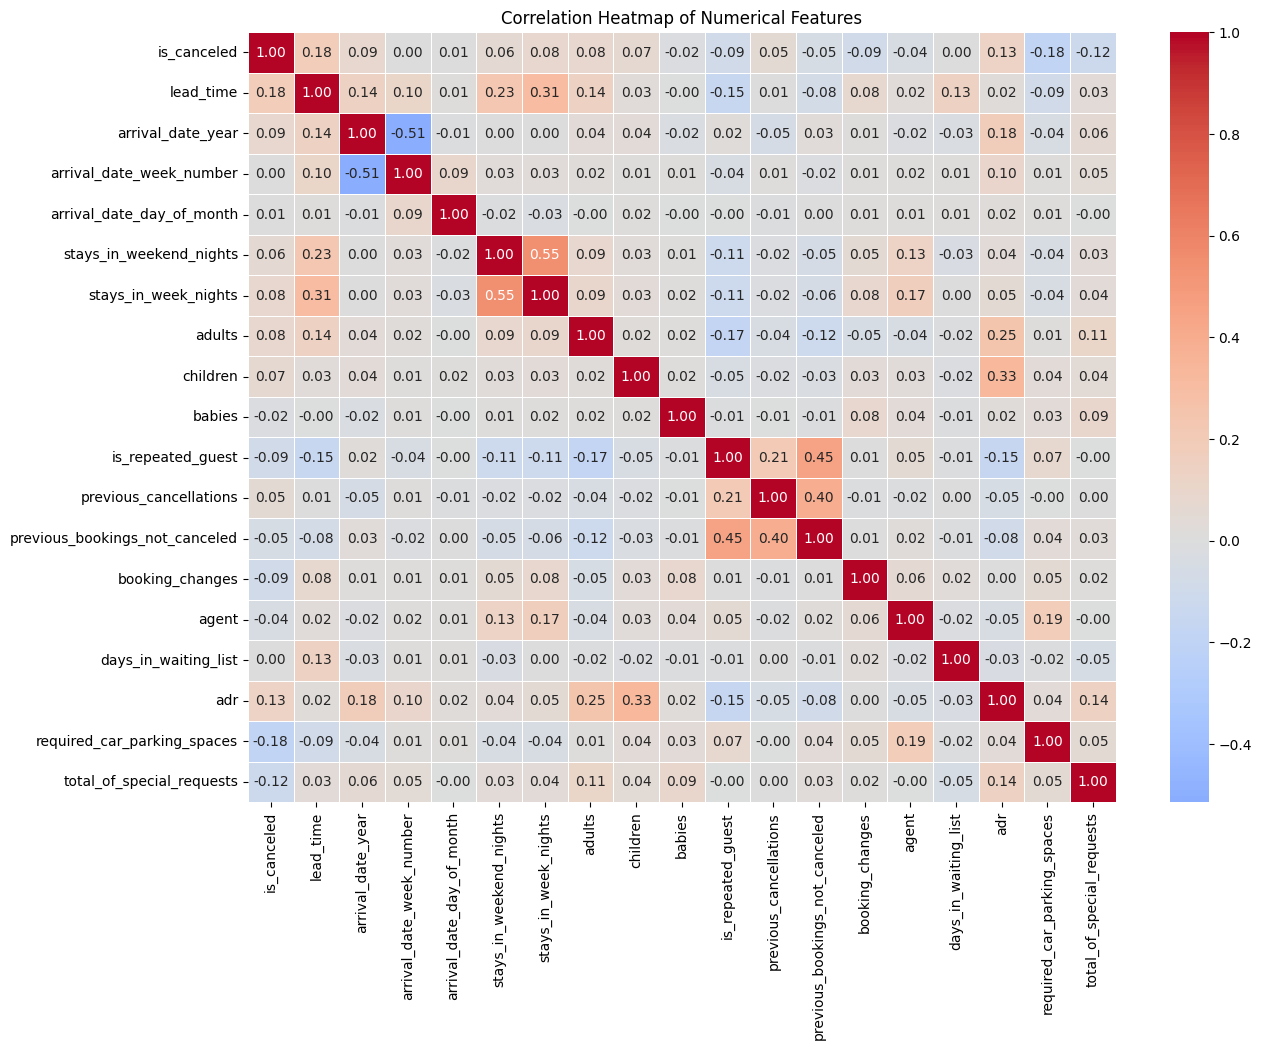

In [21]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f",cmap='coolwarm',center=0,linewidths=0.5)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## 5. Feature Selection (Drop Leakage / Low-Value Columns)

In [22]:
df.drop('agent',axis=1,inplace=True)
df.drop('arrival_date_day_of_month',axis=1,inplace=True)
df.drop('is_repeated_guest',axis=1,inplace=True)
df.drop('previous_cancellations',axis=1,inplace=True)
df.drop(['reservation_status', 'reservation_status_date'], axis=1, inplace=True)

In [23]:
df.shape

(86933, 25)

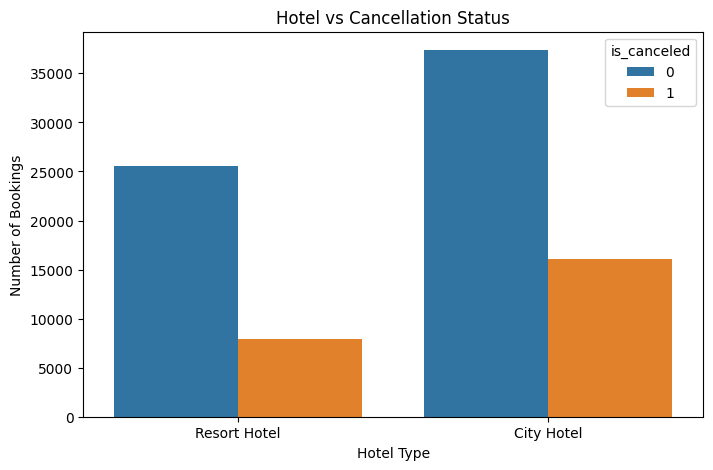

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='hotel',hue='is_canceled')
plt.title("Hotel vs Cancellation Status")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

plt.show()

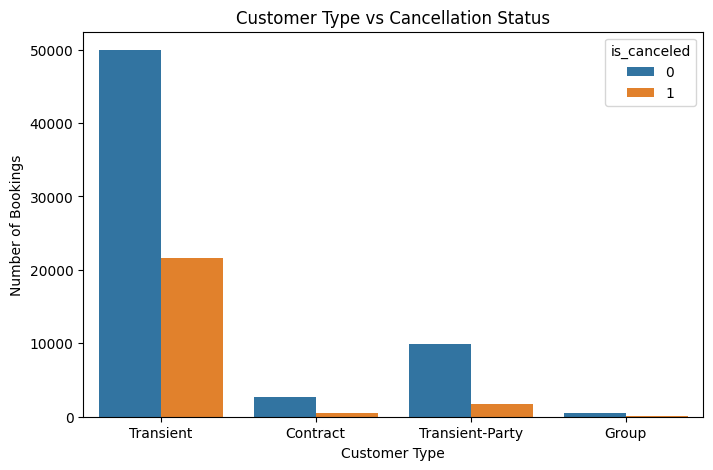

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='customer_type',hue='is_canceled')
plt.title("Customer Type vs Cancellation Status")
plt.xlabel("Customer Type")
plt.ylabel("Number of Bookings")

plt.show()

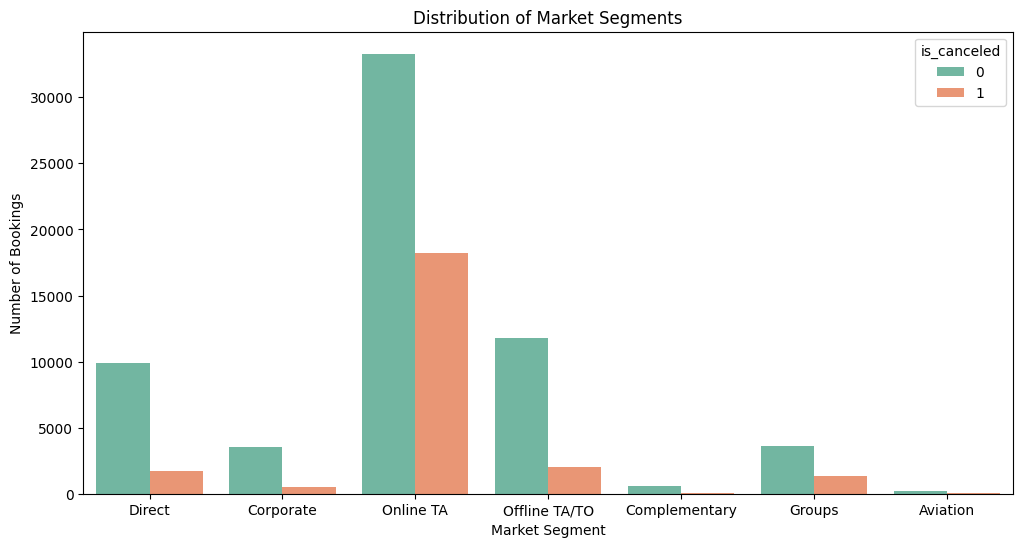

In [26]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='market_segment', palette='Set2',hue='is_canceled')
plt.title("Distribution of Market Segments")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")
plt.show()

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86933 entries, 0 to 86932
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           86933 non-null  object 
 1   is_canceled                     86933 non-null  int64  
 2   lead_time                       86933 non-null  int64  
 3   arrival_date_year               86933 non-null  int64  
 4   arrival_date_month              86933 non-null  object 
 5   arrival_date_week_number        86933 non-null  int64  
 6   stays_in_weekend_nights         86933 non-null  int64  
 7   stays_in_week_nights            86933 non-null  int64  
 8   adults                          86933 non-null  int64  
 9   children                        86933 non-null  float64
 10  babies                          86933 non-null  int64  
 11  meal                            86933 non-null  object 
 12  country                         

## 6. Final Checks Before Encoding

In [28]:
df.isna().sum()


hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
dtype: int64

In [29]:
df['is_canceled'].value_counts(normalize=True)

is_canceled
0    0.724075
1    0.275925
Name: proportion, dtype: float64

In [30]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
is_canceled,86933.0,0.275925,0.446982,0.00,0.00,0.0,1.0,1.0
lead_time,86933.0,80.199257,86.101083,0.00,12.00,50.0,125.0,737.0
arrival_date_year,86933.0,2016.211841,0.686007,2015.00,2016.00,2016.0,2017.0,2017.0
arrival_date_week_number,86933.0,26.840900,13.654282,1.00,16.00,27.0,37.0,53.0
stays_in_weekend_nights,86933.0,1.007454,1.028776,0.00,0.00,1.0,2.0,16.0
stays_in_week_nights,86933.0,2.628898,2.043760,0.00,1.00,2.0,4.0,41.0
adults,86933.0,1.878573,0.625850,0.00,2.00,2.0,2.0,55.0
children,86933.0,0.139222,0.456803,0.00,0.00,0.0,0.0,10.0
babies,86933.0,0.010836,0.113597,0.00,0.00,0.0,0.0,10.0
previous_bookings_not_canceled,86933.0,0.176722,1.717954,0.00,0.00,0.0,0.0,72.0


In [31]:
df['is_canceled']=df['is_canceled'].astype(int)

## 7. Encoding

In [32]:
categorical_col=df.select_dtypes(include='object').columns

In [33]:
categorical_col

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object')

In [34]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(sparse_output=False).set_output(transform='pandas')

In [35]:
x=ohe.fit_transform(df[categorical_col])
df = pd.concat([df.drop(columns=categorical_col), x], axis=1)

In [36]:
df.shape

(86933, 252)

## 8. Train/Test Split (Baseline Models)

In [37]:
X=df.drop('is_canceled',axis=1)
y=df['is_canceled']

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                   test_size= 0.20, random_state=100,stratify=y)

In [39]:
print("X_train = ",X_train.shape ," y_train = ", y_train.shape)
print("X_test  = ",X_test.shape ," y_test  = ", y_test.shape)

X_train =  (69546, 251)  y_train =  (69546,)
X_test  =  (17387, 251)  y_test  =  (17387,)


## 9. Baseline Model Comparison (12 Models)

In [40]:
models = {

    # Linear
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=1),

    # Distance-based
    "KNN": KNeighborsClassifier(n_neighbors=5),

    # SVM
    # "SVC": SVC(probability=True, random_state=1),

    # Tree
    "Decision Tree": DecisionTreeClassifier(random_state=1),

    # Naive Bayes
    "Naive Bayes": GaussianNB(),

    # Bagging Based
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=1),

    # Boosting
    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=1),

    # External Boosting Libraries
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=1, use_label_encoder=False),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=1),
    "LightGBM": LGBMClassifier(random_state=1)
}

  0%|          | 0/12 [00:00<?, ?it/s]


Confusion Matrix:
 [[11538  1051]
 [ 2612  2186]]


c:\Users\youss\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


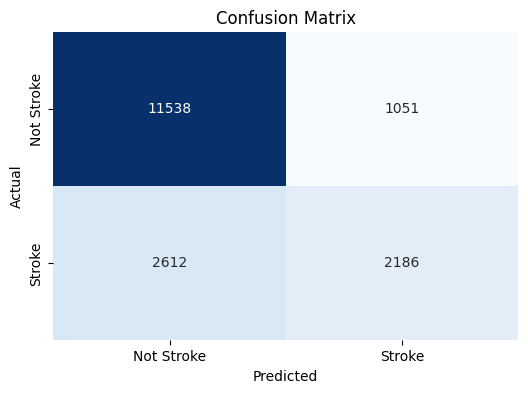


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.82      0.92      0.86     12589
      Stroke       0.68      0.46      0.54      4798

    accuracy                           0.79     17387
   macro avg       0.75      0.69      0.70     17387
weighted avg       0.78      0.79      0.78     17387

ROC-AUC: 0.8377941966909651


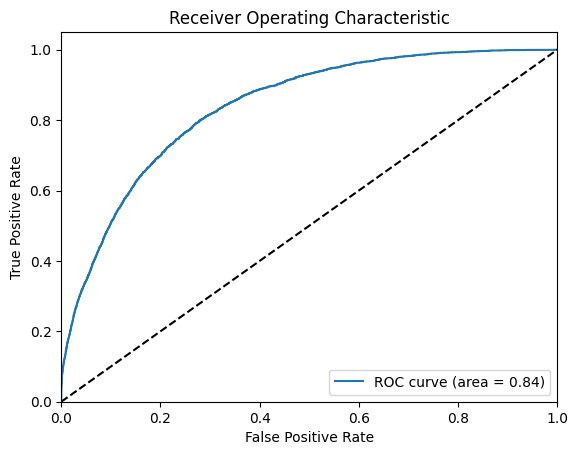

PR AUC: 0.6667169462895299


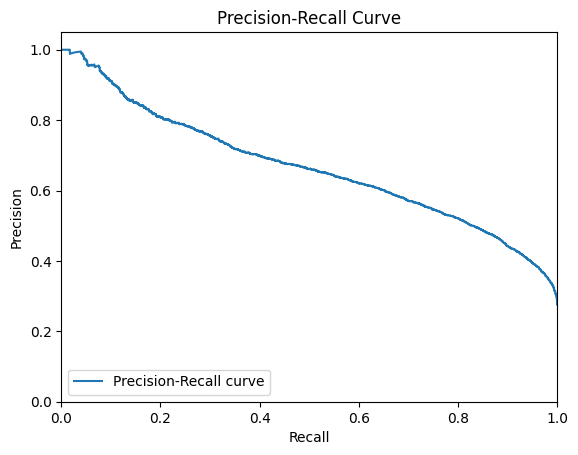

  8%|▊         | 1/12 [00:58<10:40, 58.26s/it]


Confusion Matrix:
 [[10667  1922]
 [ 3069  1729]]


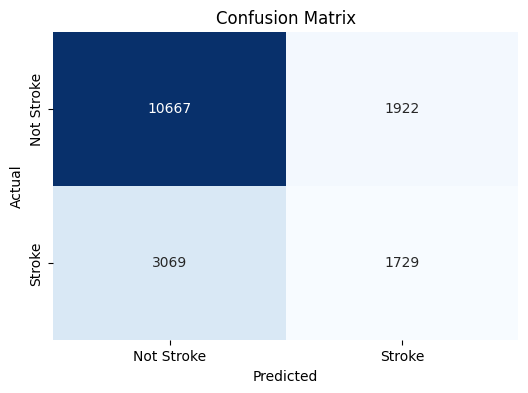


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.78      0.85      0.81     12589
      Stroke       0.47      0.36      0.41      4798

    accuracy                           0.71     17387
   macro avg       0.63      0.60      0.61     17387
weighted avg       0.69      0.71      0.70     17387

ROC-AUC: 0.6883803823653454


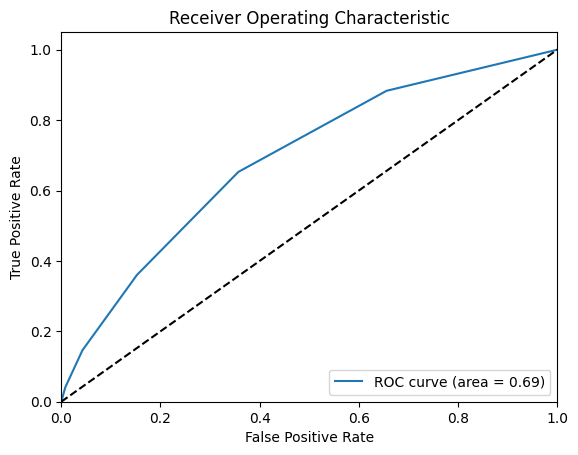

PR AUC: 0.4184792625478252


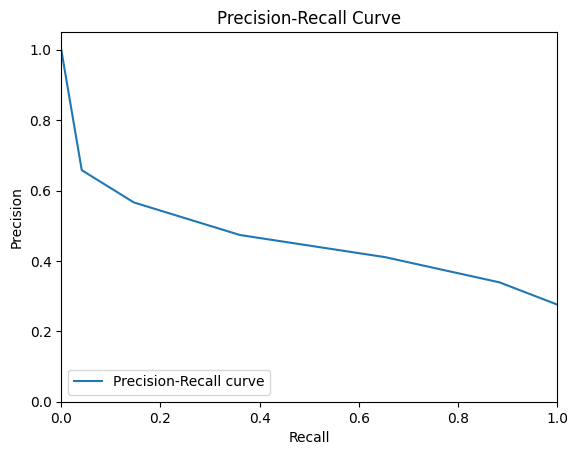

 17%|█▋        | 2/12 [01:34<07:34, 45.48s/it]


Confusion Matrix:
 [[10714  1875]
 [ 1789  3009]]


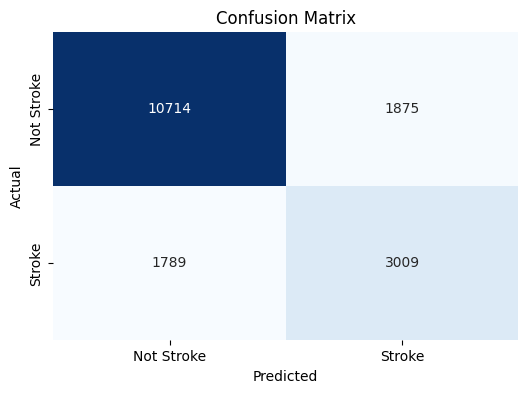


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.86      0.85      0.85     12589
      Stroke       0.62      0.63      0.62      4798

    accuracy                           0.79     17387
   macro avg       0.74      0.74      0.74     17387
weighted avg       0.79      0.79      0.79     17387

ROC-AUC: 0.7417309970186099


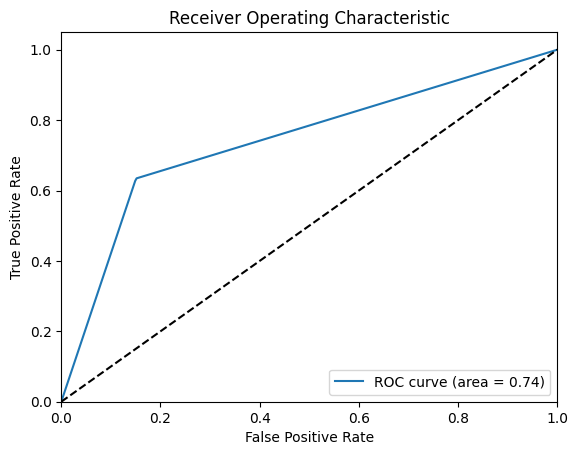

PR AUC: 0.4917670572792485


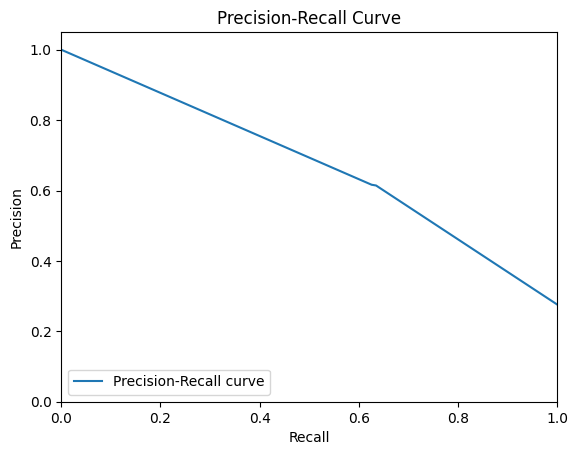

 25%|██▌       | 3/12 [01:37<03:51, 25.74s/it]


Confusion Matrix:
 [[3223 9366]
 [ 319 4479]]


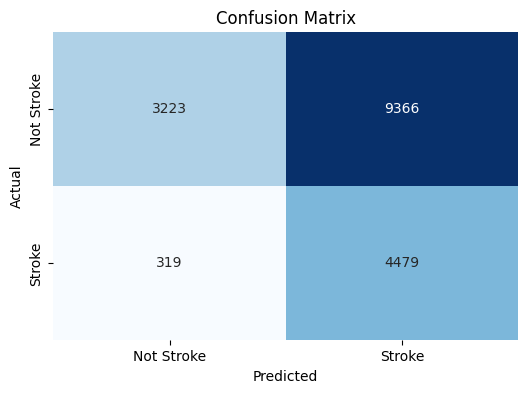


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.91      0.26      0.40     12589
      Stroke       0.32      0.93      0.48      4798

    accuracy                           0.44     17387
   macro avg       0.62      0.59      0.44     17387
weighted avg       0.75      0.44      0.42     17387

ROC-AUC: 0.7257670198524149


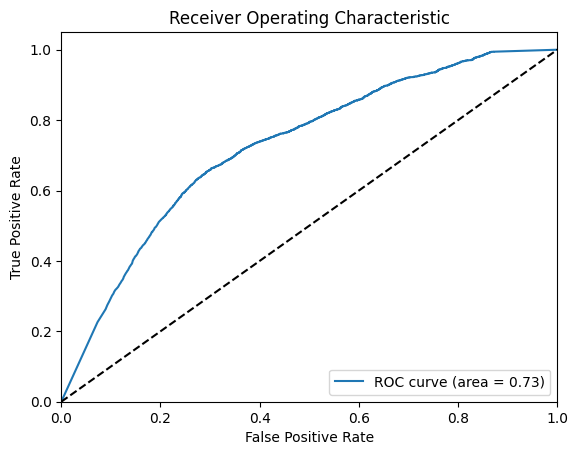

PR AUC: 0.466384485908504


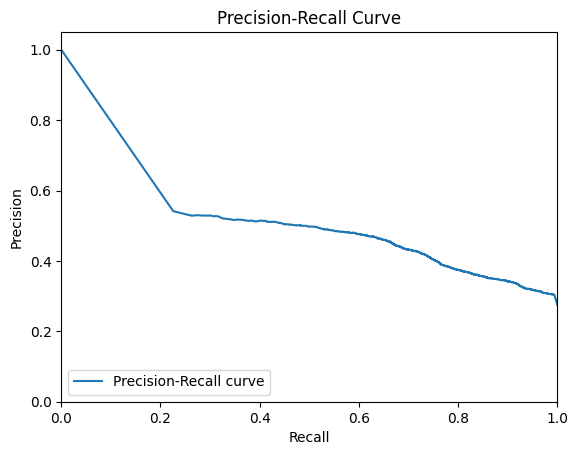

 33%|███▎      | 4/12 [01:38<02:08, 16.12s/it]


Confusion Matrix:
 [[11690   899]
 [ 1853  2945]]


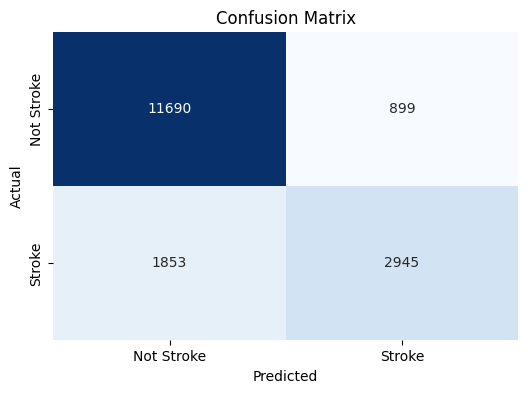


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.86      0.93      0.89     12589
      Stroke       0.77      0.61      0.68      4798

    accuracy                           0.84     17387
   macro avg       0.81      0.77      0.79     17387
weighted avg       0.84      0.84      0.84     17387

ROC-AUC: 0.8957826776063887


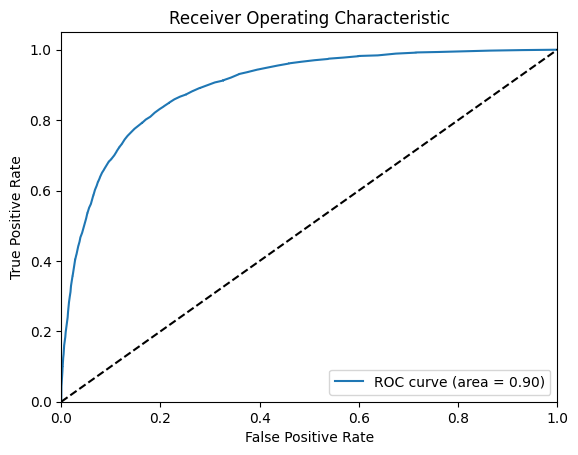

PR AUC: 0.7684091068179256


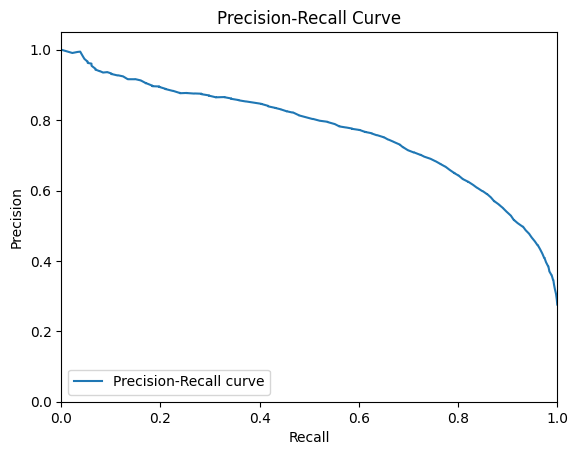

 42%|████▏     | 5/12 [02:00<02:07, 18.25s/it]


Confusion Matrix:
 [[11505  1084]
 [ 1896  2902]]


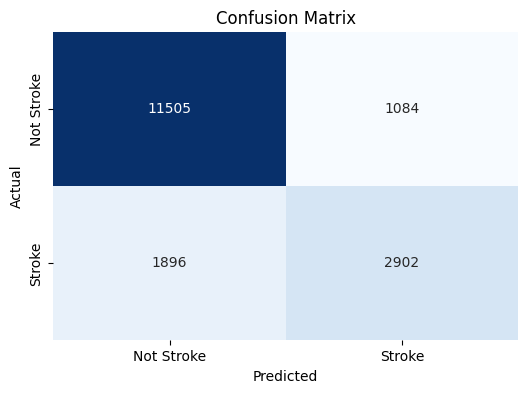


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.86      0.91      0.89     12589
      Stroke       0.73      0.60      0.66      4798

    accuracy                           0.83     17387
   macro avg       0.79      0.76      0.77     17387
weighted avg       0.82      0.83      0.82     17387

ROC-AUC: 0.8787928159093747


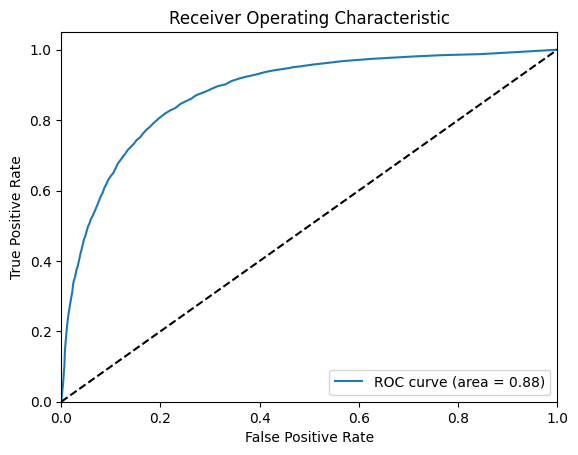

PR AUC: 0.728876160070453


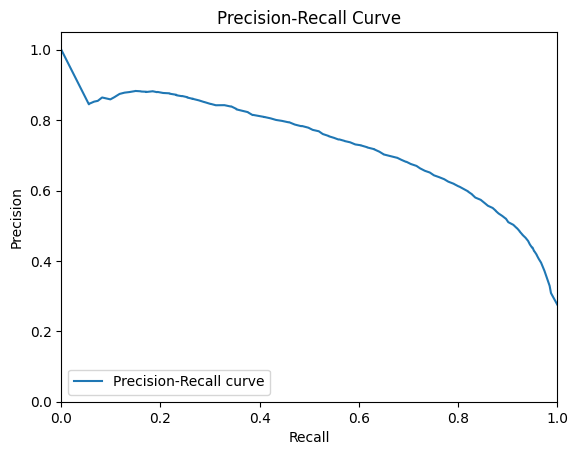

 50%|█████     | 6/12 [02:35<02:23, 23.90s/it]


Confusion Matrix:
 [[11634   955]
 [ 2695  2103]]


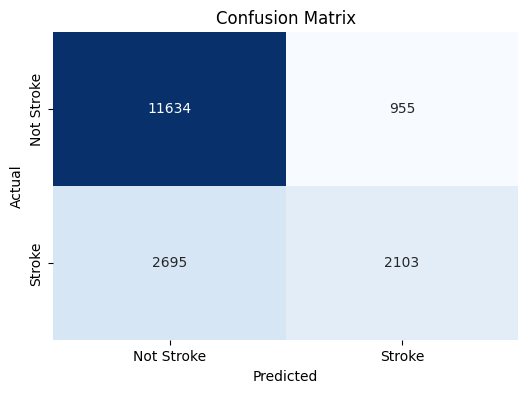


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.81      0.92      0.86     12589
      Stroke       0.69      0.44      0.54      4798

    accuracy                           0.79     17387
   macro avg       0.75      0.68      0.70     17387
weighted avg       0.78      0.79      0.77     17387

ROC-AUC: 0.8215835804304696


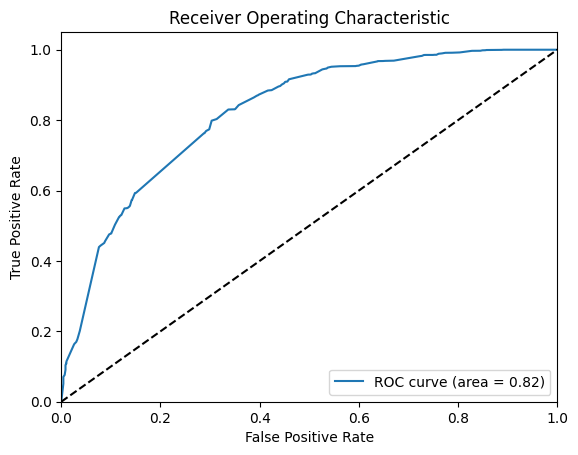

PR AUC: 0.6042444839440846


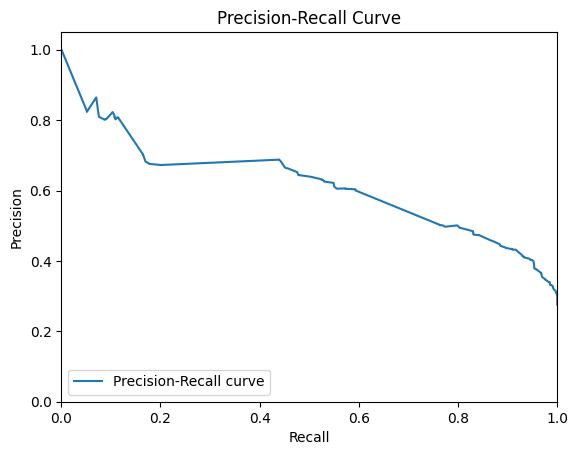

 58%|█████▊    | 7/12 [02:48<01:42, 20.43s/it]


Confusion Matrix:
 [[11563  1026]
 [ 2159  2639]]


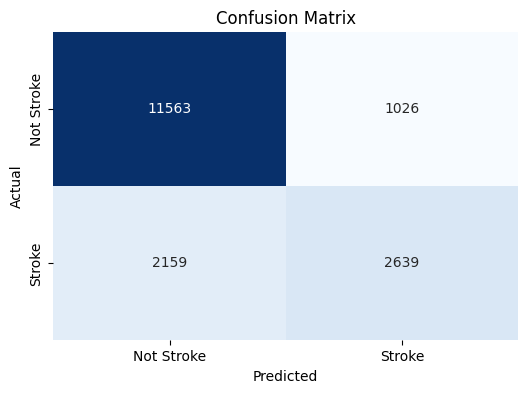


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.84      0.92      0.88     12589
      Stroke       0.72      0.55      0.62      4798

    accuracy                           0.82     17387
   macro avg       0.78      0.73      0.75     17387
weighted avg       0.81      0.82      0.81     17387

ROC-AUC: 0.875813039834991


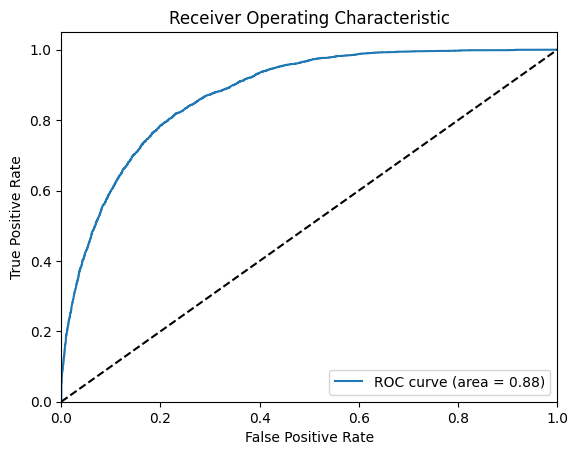

PR AUC: 0.7258141392241093


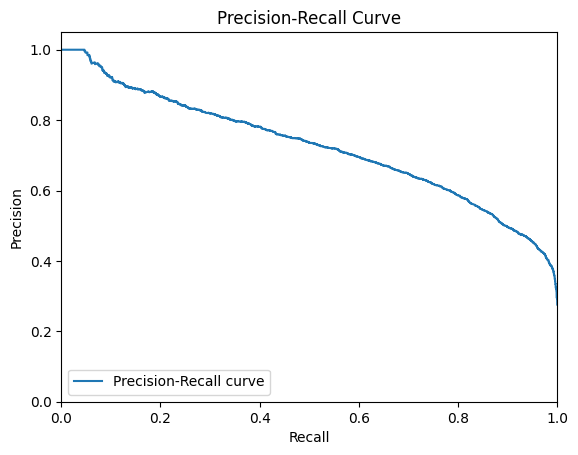

 67%|██████▋   | 8/12 [03:21<01:37, 24.27s/it]


Confusion Matrix:
 [[11497  1092]
 [ 1714  3084]]


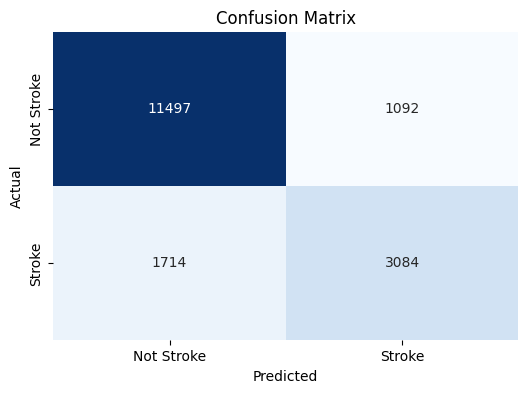


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.87      0.91      0.89     12589
      Stroke       0.74      0.64      0.69      4798

    accuracy                           0.84     17387
   macro avg       0.80      0.78      0.79     17387
weighted avg       0.83      0.84      0.83     17387

ROC-AUC: 0.9014694408740158


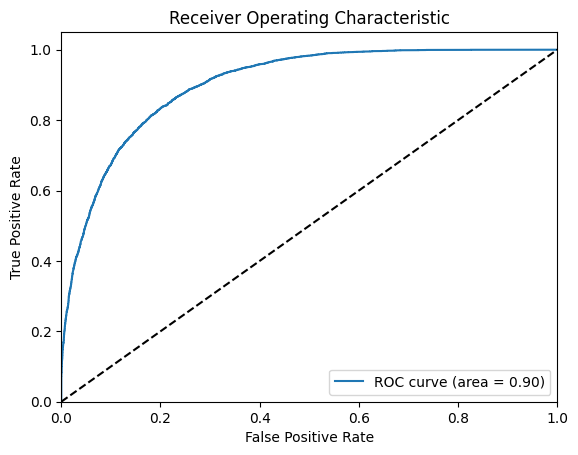

PR AUC: 0.7784633405616235


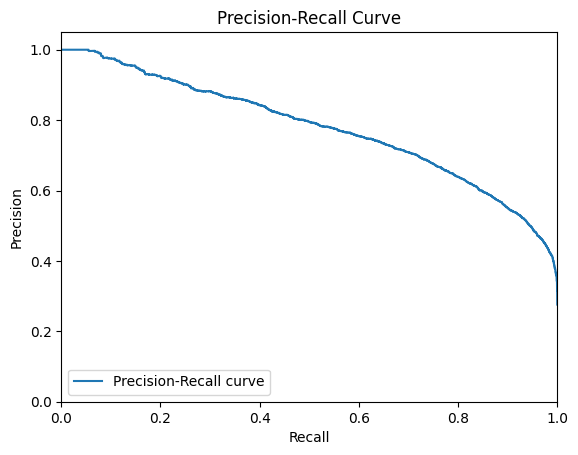

 75%|███████▌  | 9/12 [03:27<00:56, 18.67s/it]c:\Users\youss\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [05:36:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Confusion Matrix:
 [[11511  1078]
 [ 1665  3133]]


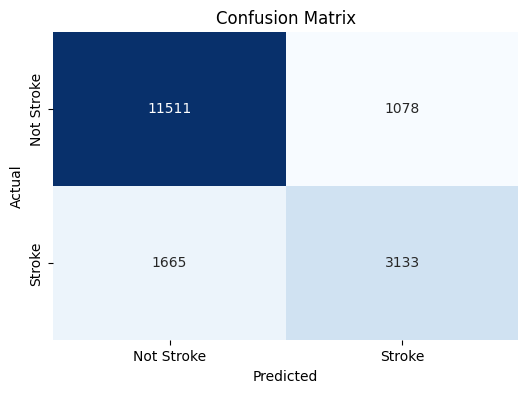


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.87      0.91      0.89     12589
      Stroke       0.74      0.65      0.70      4798

    accuracy                           0.84     17387
   macro avg       0.81      0.78      0.79     17387
weighted avg       0.84      0.84      0.84     17387

ROC-AUC: 0.904830644576766


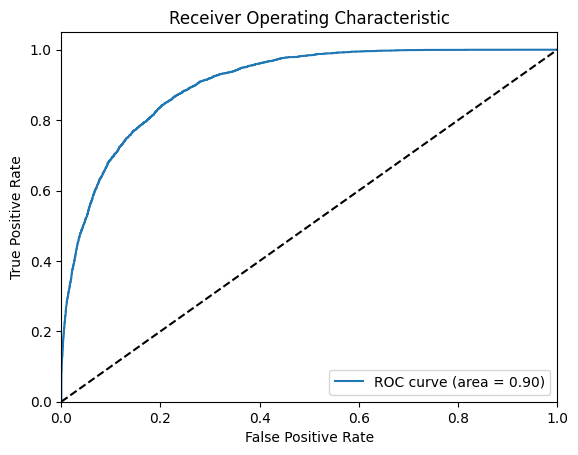

PR AUC: 0.7879372933211


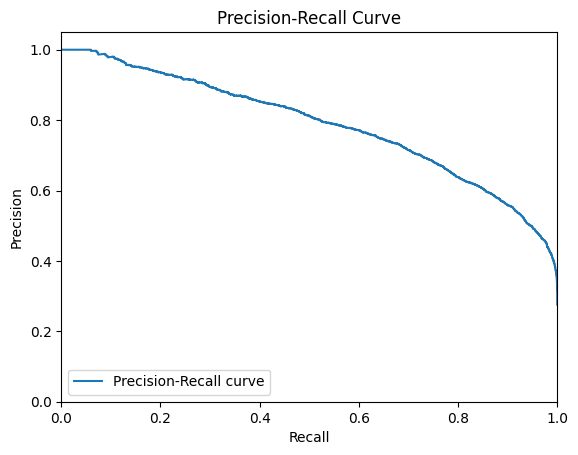

 83%|████████▎ | 10/12 [03:30<00:27, 13.97s/it]


Confusion Matrix:
 [[11542  1047]
 [ 1648  3150]]


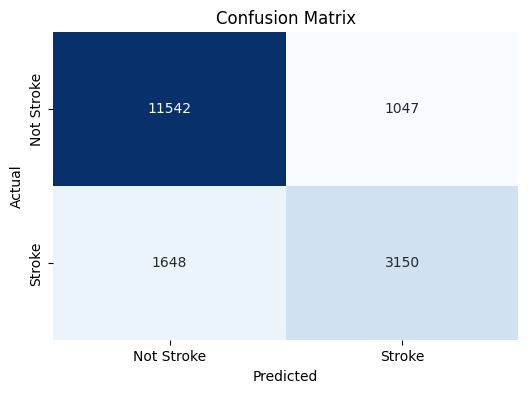


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.88      0.92      0.90     12589
      Stroke       0.75      0.66      0.70      4798

    accuracy                           0.84     17387
   macro avg       0.81      0.79      0.80     17387
weighted avg       0.84      0.84      0.84     17387

ROC-AUC: 0.907323698534463


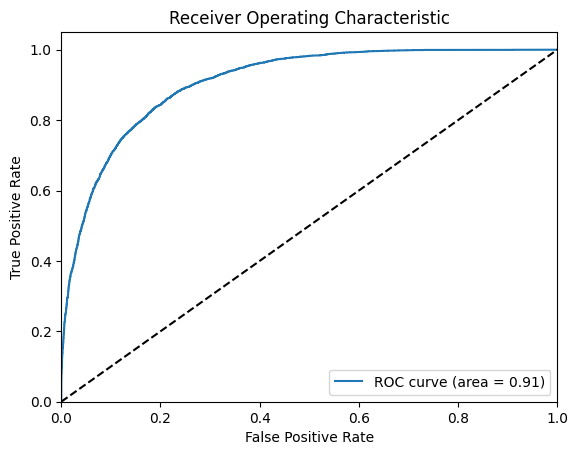

PR AUC: 0.7929624370612535


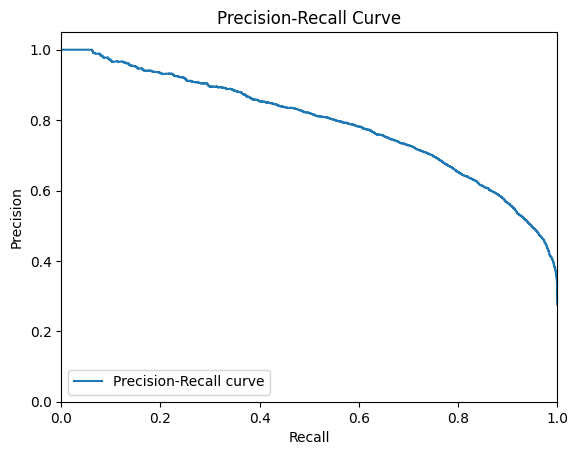

 92%|█████████▏| 11/12 [03:45<00:14, 14.16s/it]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 19189, number of negative: 50357
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005676 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1028
[LightGBM] [Info] Number of data points in the train set: 69546, number of used features: 136
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.275918 -> initscore=-0.964800
[LightGBM] [Info] Start training from score -0.964800

Confusion Matrix:
 [[11508  1081]
 [ 1734  3064]]


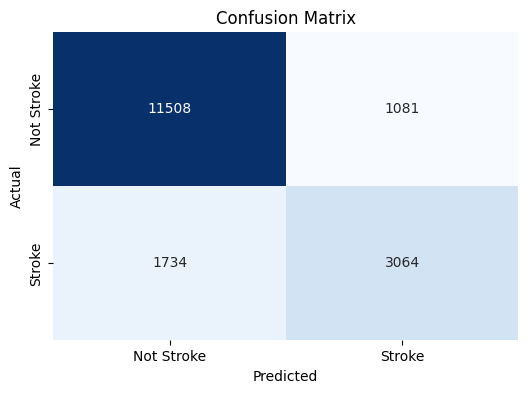


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.87      0.91      0.89     12589
      Stroke       0.74      0.64      0.69      4798

    accuracy                           0.84     17387
   macro avg       0.80      0.78      0.79     17387
weighted avg       0.83      0.84      0.83     17387

ROC-AUC: 0.902024422295002


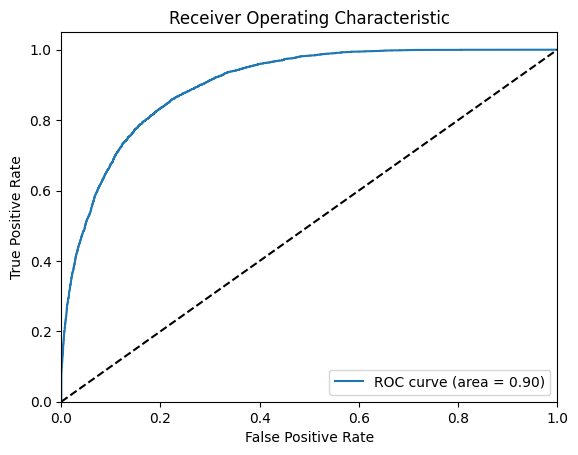

PR AUC: 0.7802216851486851


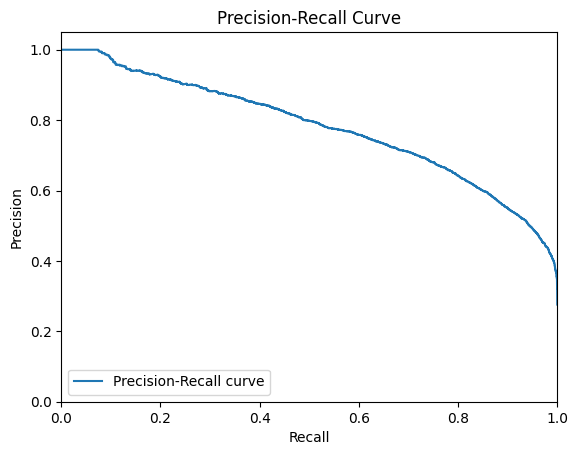

100%|██████████| 12/12 [03:47<00:00, 18.94s/it]


In [41]:
results = {}

for name, model in tqdm(models.items()):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)



    cm = confusion_matrix(y_test, test_pred)
    print("\nConfusion Matrix:\n", cm)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm,annot=True,fmt="d",cmap='Blues',cbar=False,
                xticklabels=['Not Stroke','Stroke']
                ,yticklabels=['Not Stroke','Stroke'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

    # Full classification report
    print("\nClassification Report:\n")
    print(classification_report(y_test, test_pred,target_names=['Not Stroke','Stroke'],zero_division=0))

    y_pred_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    print("ROC-AUC:", roc_auc)

    # ROC curve
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_prob)
    plt.figure()
    plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

    pr_auc = average_precision_score(y_test, y_pred_prob)
    print("PR AUC:", pr_auc)

    precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)
    plt.figure()
    plt.plot(recall_vals, precision_vals, label='Precision-Recall curve')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

    results[name] = {
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train Precision": precision_score(y_train, train_pred),
        "Test Precision": precision_score(y_test, test_pred),
        "Train Recall": recall_score(y_train, train_pred),
        "Test Recall": recall_score(y_test, test_pred),
        "Train F1 Score": f1_score(y_train, train_pred),
        "Test F1 Score": f1_score(y_test, test_pred),
        "Train Balanced Accuracy": balanced_accuracy_score(y_train, train_pred),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, test_pred),
        "ROC-AUC": roc_auc,
        "PR AUC": pr_auc

    }


In [42]:
for name, metrics in results.items():
    print(f"{name}: {metrics['Test Accuracy']:.4f}")

Logistic Regression: 0.7893
KNN: 0.7129
Decision Tree: 0.7893
Naive Bayes: 0.4430
Random Forest: 0.8417
Extra Trees: 0.8286
AdaBoost: 0.7901
Gradient Boosting: 0.8168
Hist Gradient Boosting: 0.8386
XGBoost: 0.8422
CatBoost: 0.8450
LightGBM: 0.8381


In [43]:
voting_model = VotingClassifier(
    estimators=[
        ("lr", models["Logistic Regression"]),
        ("rf", models["Random Forest"]),
        ("nb", models["Naive Bayes"]),
        ("xgb", models["XGBoost"]),
    ],
    voting="soft" # voting='hard' / voting='soft', weights=[2, 1, 2,1]
)

voting_model.fit(X_train, y_train)
voting_train_pred = voting_model.predict(X_train)
voting_test_pred = voting_model.predict(X_test)

y_pred_prob = voting_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)

voting_test_accuracy = accuracy_score(y_test, voting_test_pred)
print(f"Voting Classifier: {voting_test_accuracy:.4f}")

results["Voting Classifier"] = {
    "Train Accuracy": accuracy_score(y_train, voting_train_pred),
    "Test Accuracy": voting_test_accuracy,
    "Train Precision": precision_score(y_train, voting_train_pred),
    "Test Precision": precision_score(y_test, voting_test_pred),
    "Train Recall": recall_score(y_train, voting_train_pred),
    "Test Recall": recall_score(y_test, voting_test_pred),
    "Train F1 Score": f1_score(y_train, voting_train_pred),
    "Test F1 Score": f1_score(y_test, voting_test_pred),
    "Train Balanced Accuracy": balanced_accuracy_score(y_train, voting_train_pred),
    "Test Balanced Accuracy": balanced_accuracy_score(y_test, voting_test_pred),
    "ROC-AUC": roc_auc,
    "PR AUC": pr_auc
}


c:\Users\youss\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\youss\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [05:38:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Voting Classifier: 0.8229


In [44]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test F1 Score", ascending=False)

In [45]:
results_df[["Test Accuracy", "Train Accuracy"]].plot.bar(figsize=(12,6))

<Axes: >

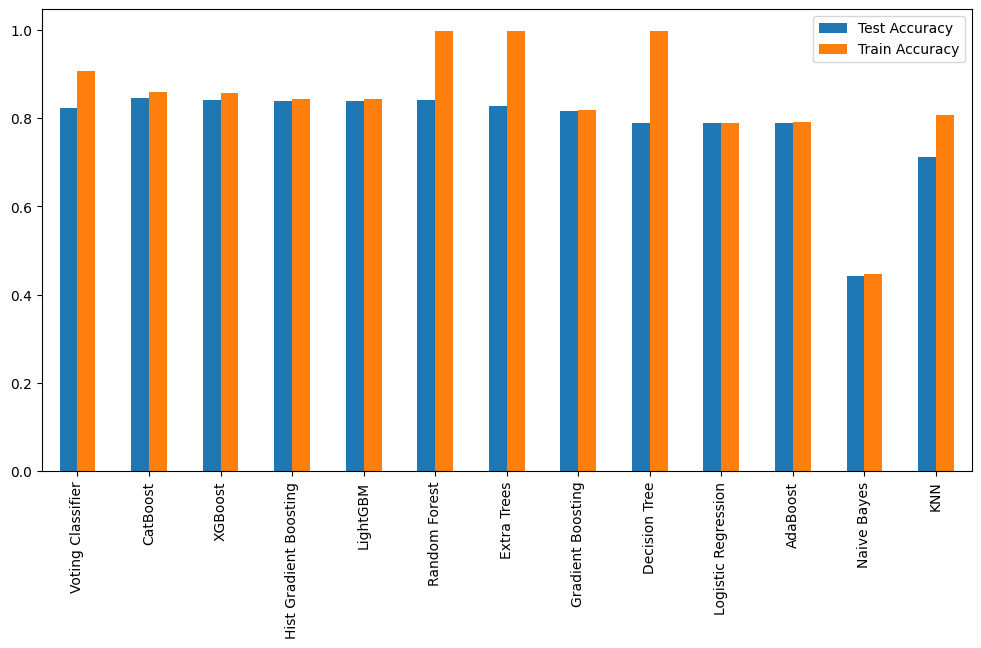

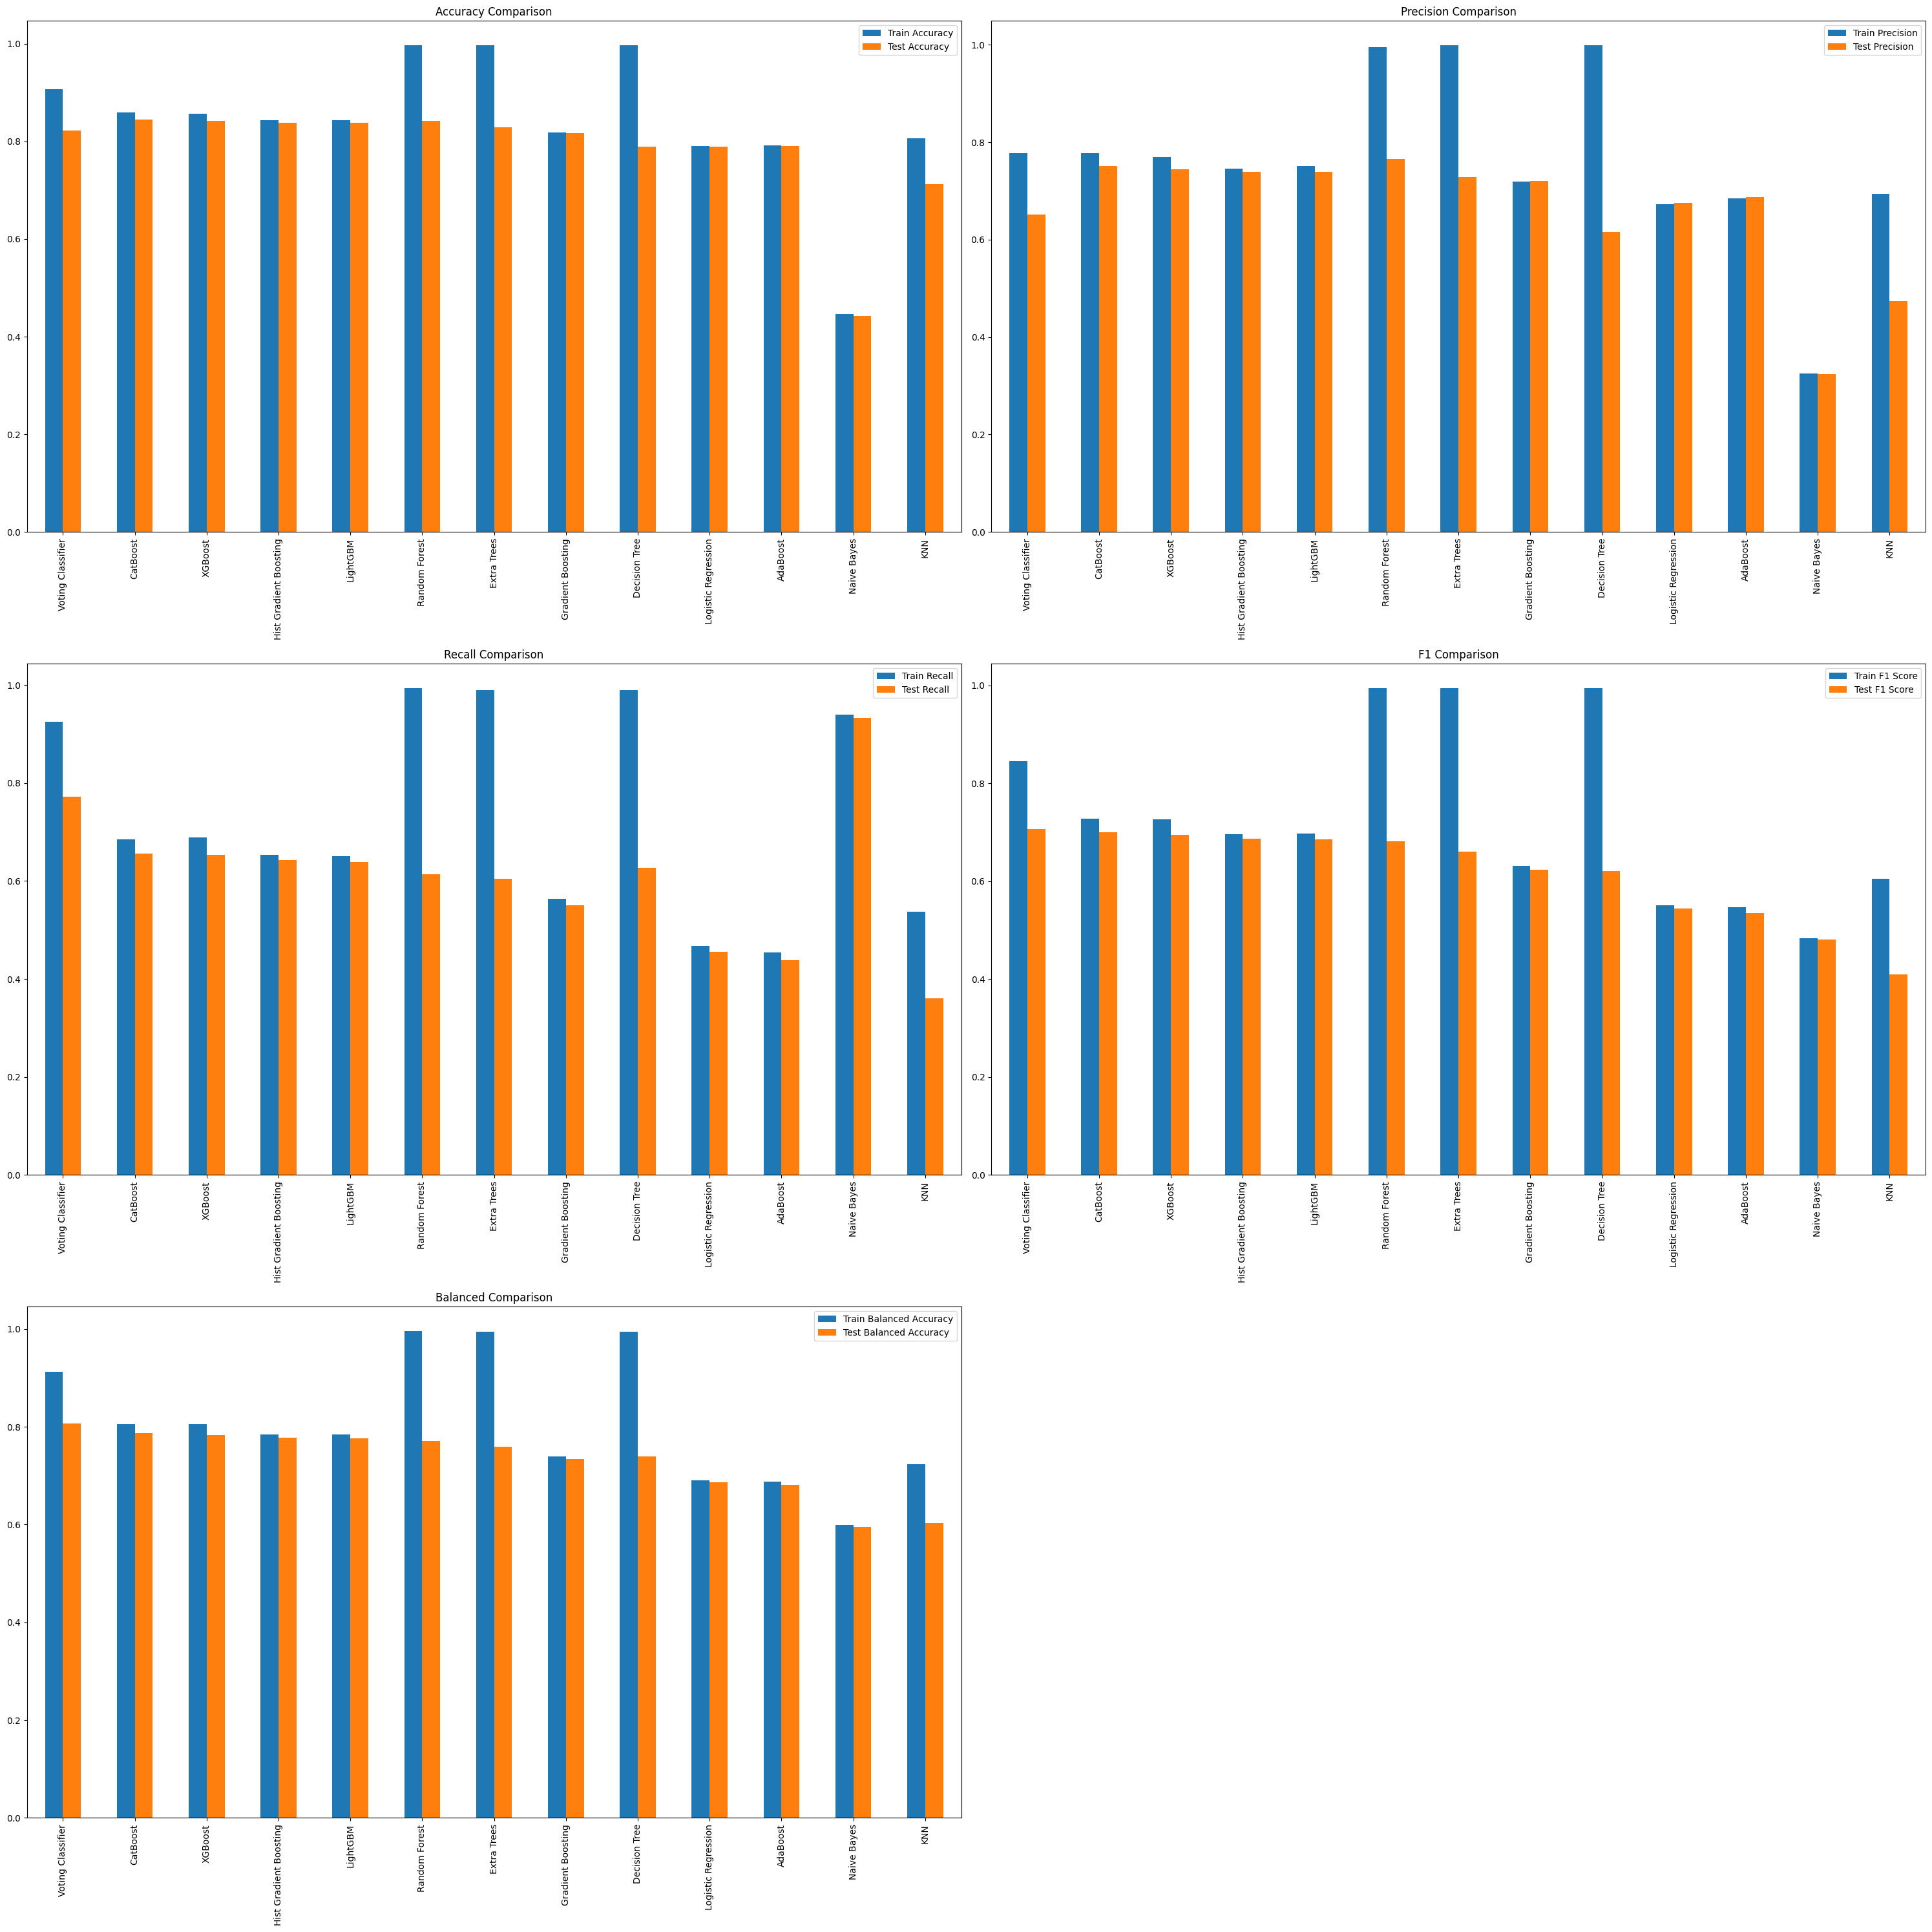

In [46]:
cols = [
    ['Train Accuracy', 'Test Accuracy'],
    ['Train Precision', 'Test Precision'],
    ['Train Recall', 'Test Recall'],
    ['Train F1 Score', 'Test F1 Score'],
    ["Train Balanced Accuracy", "Test Balanced Accuracy"]
]

plt.figure(figsize=(30,30))

for i, col in enumerate(cols):
    ax = plt.subplot(3, 2, i+1)
    results_df[col].plot.bar(ax=ax)
    ax.set_title(col[0].split(" ")[1] + ' Comparison')

plt.tight_layout()
plt.show()

## 🚀 Production Pipeline + Grid Search (XGBoost) + Deployment prep

This section is self-contained: it reloads the raw CSV, cleans it the same way as
above (drops leaky columns, duplicates, missing values), keeps only the **12
features** used for the Gradio app, builds a single `sklearn` `Pipeline`
(preprocessing + XGBoost), tunes it with `RandomizedSearchCV` over a wide hyperparameter space, evaluates it, then
saves the whole pipeline as one `.pkl` file so `app.py` doesn't need any of
the notebook's manual preprocessing code.


In [47]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
import joblib


In [ ]:
raw = pd.read_csv(path + '/hotel_bookings.csv')

raw.drop('company', axis=1, inplace=True)
raw.drop_duplicates(inplace=True)
raw.reset_index(drop=True, inplace=True)
raw.dropna(subset=['country', 'children'], inplace=True)
raw.reset_index(drop=True, inplace=True)


raw.drop(['reservation_status', 'reservation_status_date'], axis=1, inplace=True)

raw.shape


(86933, 29)

In [ ]:
NUMERIC_FEATURES = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'booking_changes',
    'adr',
    'total_of_special_requests',
    'required_car_parking_spaces',
    'previous_bookings_not_canceled',
]

CATEGORICAL_FEATURES = [
    'deposit_type',
    'customer_type',
    'market_segment',
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = 'is_canceled'

X = raw[FEATURES].copy()
y = raw[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=100, stratify=y
)

print("X_train =", X_train.shape, " X_test =", X_test.shape)


X_train = (69546, 12)  X_test = (17387, 12)


In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), NUMERIC_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES),
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=1)),
])


In [51]:
param_grid = {
    'classifier__n_estimators': [200, 400, 600],
    'classifier__max_depth': [4, 6, 8, 10],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0],
    'classifier__min_child_weight': [1, 3, 5],
    'classifier__gamma': [0, 0.1, 0.3],
}

from sklearn.model_selection import RandomizedSearchCV

grid_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=60,          
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    random_state=1,
    verbose=2,
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params: {'classifier__subsample': 0.7, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 1, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.1, 'classifier__gamma': 0, 'classifier__colsample_bytree': 1.0}
Best CV Accuracy: 0.7960774788616508


Train Accuracy: 0.8078681735829523
Test Accuracy : 0.8005981480416403

              precision    recall  f1-score   support

Not Canceled       0.82      0.93      0.87     12589
    Canceled       0.71      0.47      0.56      4798

    accuracy                           0.80     17387
   macro avg       0.77      0.70      0.72     17387
weighted avg       0.79      0.80      0.79     17387



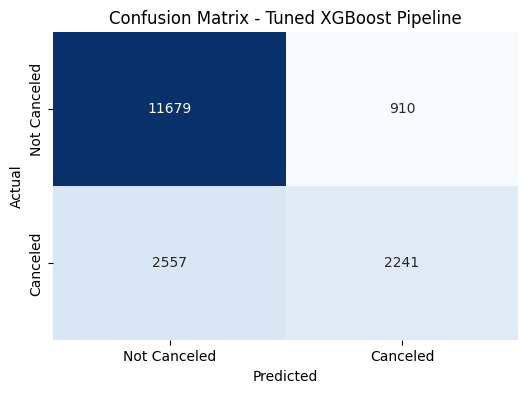

In [52]:
best_pipeline = grid_search.best_estimator_

train_pred = best_pipeline.predict(X_train)
test_pred = best_pipeline.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))
print()
print(classification_report(y_test, test_pred, target_names=['Not Canceled', 'Canceled']))

cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Tuned XGBoost Pipeline')
plt.show()


In [53]:
# Save the ENTIRE pipeline (preprocessing + model) as one file.
# app.py only needs to load this one .pkl - no manual preprocessing required.
joblib.dump(best_pipeline, 'hotel_cancellation_pipeline.pkl')
print("Saved -> hotel_cancellation_pipeline.pkl")


Saved -> hotel_cancellation_pipeline.pkl
